## Import Library

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import glob

# Data wrangling

### 1. Gathering Data

In [3]:
aotizhongxin_df = pd.read_csv('data/PRSA_Data_Aotizhongxin_20130301-20170228.csv')
changping_df = pd.read_csv('data/PRSA_Data_Changping_20130301-20170228.csv')
dingling_df = pd.read_csv('data/PRSA_Data_Dingling_20130301-20170228.csv')
dongsi_df = pd.read_csv('data/PRSA_Data_Dongsi_20130301-20170228.csv')
guanyuan_df = pd.read_csv('data/PRSA_Data_Guanyuan_20130301-20170228.csv')
gucheng_df = pd.read_csv('data/PRSA_Data_Gucheng_20130301-20170228.csv')
huairou_df = pd.read_csv('data/PRSA_Data_Huairou_20130301-20170228.csv')
nongzhanguan_df = pd.read_csv('data/PRSA_Data_Nongzhanguan_20130301-20170228.csv')
shunyi_df = pd.read_csv('data/PRSA_Data_Shunyi_20130301-20170228.csv')
tiantan_df = pd.read_csv('data/PRSA_Data_Tiantan_20130301-20170228.csv')
wanliu_df = pd.read_csv('data/PRSA_Data_Wanliu_20130301-20170228.csv')
wanshouxigong_df = pd.read_csv('data/PRSA_Data_Wanshouxigong_20130301-20170228.csv')
aotizhongxin_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


### 2. Assesing data

Aotizhongxin_df table

In [4]:
aotizhongxin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [5]:
print(f'Jumlah Duplikasi : {aotizhongxin_df.duplicated().sum()}')

Jumlah Duplikasi : 0


In [6]:
aotizhongxin_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34139.000000,34346.000000,34129.000000,34041.000000,33288.000000,33345.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.773611,110.060391,17.375901,59.305833,1262.945145,56.353358,13.584607,1011.846920,3.123062,0.067421,1.708496
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.135694,95.223005,22.823017,37.116200,1221.436236,57.916327,11.399097,10.404047,13.688896,0.910056,1.204071
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,30.000000,500.000000,8.000000,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,58.000000,87.000000,9.000000,53.000000,900.000000,42.000000,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,114.000000,155.000000,21.000000,82.000000,1500.000000,82.000000,23.300000,1020.100000,15.600000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,898.000000,984.000000,341.000000,290.000000,10000.000000,423.000000,40.500000,1042.000000,28.500000,72.500000,11.200000


Insight :
- terdapat data missing di berapa kolom akan kita isi rerata untuk type data float, dan untuk type data object akan di drop 

changping_df table

In [7]:
changping_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34290 non-null  float64
 6   PM10     34482 non-null  float64
 7   SO2      34436 non-null  float64
 8   NO2      34397 non-null  float64
 9   CO       33543 non-null  float64
 10  O3       34460 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  object 
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [8]:
print(f'Jumlah Duplikasi : {changping_df.duplicated().sum()}')

Jumlah Duplikasi : 0


In [9]:
changping_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34290.000000,34482.000000,34436.000000,34397.000000,33543.000000,34460.000000,35011.000000,35014.000000,35011.000000,35013.000000,35021.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,71.099743,94.657871,14.958906,44.182086,1152.301345,57.940003,13.686111,1007.760278,1.505495,0.060366,1.853836
std,10122.249256,1.177213,3.448752,8.800218,6.922285,72.326926,83.441738,20.975331,29.519796,1103.056282,54.316674,11.365313,10.225664,13.822099,0.752899,1.309808
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.847700,100.000000,0.214200,-16.600000,982.400000,-35.100000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,18.000000,34.000000,2.000000,22.000000,500.000000,15.636600,3.400000,999.300000,-10.200000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,46.000000,72.000000,7.000000,36.000000,800.000000,46.000000,14.700000,1007.400000,1.800000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,100.000000,131.000000,18.000000,60.358200,1400.000000,80.000000,23.300000,1016.000000,14.200000,0.000000,2.300000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,882.000000,999.000000,310.000000,226.000000,10000.000000,429.000000,41.400000,1036.500000,27.200000,52.100000,10.000000


dingling_df table

In [10]:
dingling_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34285 non-null  float64
 6   PM10     34408 non-null  float64
 7   SO2      34334 non-null  float64
 8   NO2      33830 non-null  float64
 9   CO       33052 non-null  float64
 10  O3       33850 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  object 
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [11]:
print(f'Jumlah Duplikasi : {dingling_df.duplicated().sum()}')

Jumlah Duplikasi : 0


In [12]:
dingling_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34285.000000,34408.000000,34334.000000,33830.000000,33052.000000,33850.000000,35011.000000,35014.000000,35011.000000,35013.000000,35021.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,65.989497,83.739723,11.749650,27.585467,904.896073,68.548371,13.686111,1007.760278,1.505495,0.060366,1.853836
std,10122.249256,1.177213,3.448752,8.800218,6.922285,72.267723,79.541685,15.519259,26.383882,903.306220,53.764424,11.365313,10.225664,13.822099,0.752899,1.309808
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-16.600000,982.400000,-35.100000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,14.000000,26.000000,2.000000,9.000000,300.000000,31.000000,3.400000,999.300000,-10.200000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,41.000000,60.000000,5.000000,19.000000,600.000000,61.000000,14.700000,1007.400000,1.800000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,93.000000,117.000000,15.000000,38.000000,1200.000000,90.000000,23.300000,1016.000000,14.200000,0.000000,2.300000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,881.000000,905.000000,156.000000,205.000000,10000.000000,500.000000,41.400000,1036.500000,27.200000,52.100000,10.000000


dongsi_df table

In [13]:
dongsi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34314 non-null  float64
 6   PM10     34511 non-null  float64
 7   SO2      34401 non-null  float64
 8   NO2      33463 non-null  float64
 9   CO       31867 non-null  float64
 10  O3       34400 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [14]:
print(f'Jumlah Duplikasi : {dongsi_df.duplicated().sum()}')

Jumlah Duplikasi : 0


In [15]:
dongsi_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34314.000000,34511.000000,34401.000000,33463.000000,31867.000000,34400.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,86.194297,110.336742,18.531107,53.699443,1330.069131,57.210637,13.671490,1012.547419,2.447535,0.064020,1.860785
std,10122.249256,1.177213,3.448752,8.800218,6.922285,86.575127,98.219860,22.905655,33.959230,1191.305887,58.033275,11.458418,10.266059,13.810696,0.786282,1.280368
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.642600,-16.800000,987.100000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,4.000000,27.000000,600.000000,12.000000,3.100000,1004.000000,-8.800000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,61.000000,86.000000,10.000000,47.000000,1000.000000,44.125200,14.600000,1012.200000,3.000000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,119.000000,151.000000,24.000000,73.000000,1700.000000,81.000000,23.500000,1020.900000,15.000000,0.000000,2.400000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,737.000000,955.000000,300.000000,258.000000,10000.000000,1071.000000,41.100000,1042.000000,28.800000,46.400000,10.500000


guanyuan_df table

In [16]:
guanyuan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34448 non-null  float64
 6   PM10     34635 non-null  float64
 7   SO2      34590 non-null  float64
 8   NO2      34405 non-null  float64
 9   CO       33311 non-null  float64
 10  O3       33891 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [17]:
print(f'Jumlah Duplikasi : {guanyuan_df.duplicated().sum()}')

Jumlah Duplikasi : 0


In [18]:
guanyuan_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34448.000000,34635.000000,34590.000000,34405.000000,33311.000000,33891.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.933372,109.023303,17.590941,57.901643,1271.294377,55.795044,13.584607,1011.846920,3.123062,0.067421,1.708496
std,10122.249256,1.177213,3.448752,8.800218,6.922285,80.933497,91.573709,23.600367,35.150857,1164.854945,57.436983,11.399097,10.404047,13.688896,0.910056,1.204071
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,1.000000,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,40.000000,3.000000,31.000000,500.000000,7.000000,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,89.000000,8.000000,51.000000,900.000000,41.000000,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,115.000000,149.000000,22.000000,78.000000,1600.000000,81.000000,23.300000,1020.100000,15.600000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,680.000000,999.000000,293.000000,270.000000,10000.000000,415.000000,40.500000,1042.000000,28.500000,72.500000,11.200000


gucheng_df table

In [19]:
gucheng_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34418 non-null  float64
 6   PM10     34683 non-null  float64
 7   SO2      34557 non-null  float64
 8   NO2      34396 non-null  float64
 9   CO       33663 non-null  float64
 10  O3       34335 non-null  float64
 11  TEMP     35013 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35013 non-null  float64
 14  RAIN     35021 non-null  float64
 15  wd       34905 non-null  object 
 16  WSPM     35022 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [20]:
print(f'Jumlah Duplikasi : {gucheng_df.duplicated().sum()}')

Jumlah Duplikasi : 0


In [21]:
gucheng_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34418.000000,34683.000000,34557.000000,34396.000000,33663.000000,34335.000000,35013.000000,35014.000000,35013.000000,35021.000000,35022.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,83.852089,118.861978,15.366162,55.871075,1323.974423,57.694879,13.864524,1008.829592,2.610442,0.064453,1.343310
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.796445,96.742626,21.204526,36.473860,1208.957772,57.019587,11.292857,10.103256,13.782991,0.838654,1.151064
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-15.600000,984.000000,-34.600000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,24.000000,45.000000,2.000000,26.000000,600.000000,10.000000,3.600000,1000.500000,-8.900000,0.000000,0.600000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,60.000000,99.000000,7.000000,50.000000,900.000000,45.000000,14.800000,1008.500000,3.000000,0.000000,1.000000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,115.750000,167.000000,20.000000,79.000000,1600.000000,83.000000,23.500000,1017.000000,15.300000,0.000000,1.800000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,770.000000,994.000000,500.000000,276.000000,10000.000000,450.000000,41.600000,1038.100000,27.400000,41.900000,12.000000


huairou_df table

In [22]:
huairou_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34111 non-null  float64
 6   PM10     34287 non-null  float64
 7   SO2      34084 non-null  float64
 8   NO2      33425 non-null  float64
 9   CO       33642 non-null  float64
 10  O3       33913 non-null  float64
 11  TEMP     35013 non-null  float64
 12  PRES     35011 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35009 non-null  float64
 15  wd       34762 non-null  object 
 16  WSPM     35015 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [23]:
print(f'Jumlah Duplikasi : {huairou_df.duplicated().sum()}')

Jumlah Duplikasi : 0


In [24]:
huairou_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34111.000000,34287.000000,34084.000000,33425.000000,33642.000000,33913.000000,35013.000000,35011.000000,35011.000000,35009.000000,35015.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,69.626367,91.482690,12.121553,32.497250,1022.554545,59.824713,12.445426,1007.598568,2.238619,0.067940,1.652021
std,10122.249256,1.177213,3.448752,8.800218,6.922285,71.224916,83.289578,18.896912,26.489531,898.738241,54.605746,11.751103,10.022101,14.052541,0.849046,1.199143
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.800000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,17.000000,28.000000,2.000000,12.000000,400.000000,18.000000,2.100000,999.300000,-9.600000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,47.000000,69.000000,4.000000,25.000000,800.000000,49.000000,13.600000,1007.300000,2.700000,0.000000,1.300000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,98.000000,131.000000,14.000000,46.000000,1300.000000,83.000000,22.300000,1015.500000,15.300000,0.000000,2.000000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,762.000000,993.000000,315.000000,231.000000,10000.000000,444.000000,40.300000,1036.500000,29.100000,45.900000,12.900000


nongzhanguan_df table

In [25]:
nongzhanguan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34436 non-null  float64
 6   PM10     34624 non-null  float64
 7   SO2      34618 non-null  float64
 8   NO2      34372 non-null  float64
 9   CO       33858 non-null  float64
 10  O3       34558 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [26]:
print(f'Jumlah Duplikasi : {nongzhanguan_df.duplicated().sum()}')

Jumlah Duplikasi : 0


In [27]:
nongzhanguan_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34436.000000,34624.000000,34618.000000,34372.000000,33858.000000,34558.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,84.838483,108.991096,18.689242,58.097172,1324.350198,58.534682,13.671490,1012.547419,2.447535,0.064020,1.860785
std,10122.249256,1.177213,3.448752,8.800218,6.922285,86.225344,95.341177,24.280665,36.297740,1245.166124,58.401448,11.458418,10.266059,13.810696,0.786282,1.280368
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.571200,2.000000,100.000000,0.214200,-16.800000,987.100000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,29.000000,500.000000,10.000000,3.100000,1004.000000,-8.800000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,85.000000,9.000000,51.000000,900.000000,45.000000,14.600000,1012.200000,3.000000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,116.000000,149.000000,23.000000,80.000000,1600.000000,84.000000,23.500000,1020.900000,15.000000,0.000000,2.400000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,844.000000,995.000000,257.000000,273.000000,10000.000000,390.000000,41.100000,1042.000000,28.800000,46.400000,10.500000


shunyi_df table

In [28]:
shunyi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34151 non-null  float64
 6   PM10     34516 non-null  float64
 7   SO2      33768 non-null  float64
 8   NO2      33699 non-null  float64
 9   CO       32886 non-null  float64
 10  O3       33575 non-null  float64
 11  TEMP     35013 non-null  float64
 12  PRES     35013 non-null  float64
 13  DEWP     35010 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34581 non-null  object 
 16  WSPM     35020 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [29]:
print(f'Jumlah Duplikasi : {shunyi_df.duplicated().sum()}')

Jumlah Duplikasi : 0


In [30]:
shunyi_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34151.000000,34516.000000,33768.000000,33699.000000,32886.000000,33575.000000,35013.000000,35013.000000,35010.000000,35013.000000,35020.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.491602,98.737026,13.572039,43.908865,1187.063979,55.201321,13.387969,1013.061938,2.465036,0.061094,1.807533
std,10122.249256,1.177213,3.448752,8.800218,6.922285,81.231739,89.143718,19.572068,30.996828,1156.374102,54.873726,11.483588,10.177339,13.726622,0.761668,1.287817
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,988.000000,-36.000000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,19.000000,31.000000,2.000000,19.000000,400.000000,10.000000,3.000000,1004.700000,-8.800000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,77.000000,5.000000,37.000000,800.000000,43.000000,14.400000,1012.700000,3.100000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,112.000000,138.000000,17.000000,62.000000,1500.000000,77.000000,23.200000,1021.000000,15.100000,0.000000,2.300000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,941.000000,999.000000,239.000000,258.000000,10000.000000,351.716400,40.600000,1042.800000,27.500000,37.300000,12.800000


tiantan_df table

In [31]:
tiantan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34387 non-null  float64
 6   PM10     34467 non-null  float64
 7   SO2      33946 non-null  float64
 8   NO2      34320 non-null  float64
 9   CO       33938 non-null  float64
 10  O3       34221 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [32]:
print(f'Jumlah Duplikasi : {tiantan_df.duplicated().sum()}')

Jumlah Duplikasi : 0


In [33]:
tiantan_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34387.000000,34467.000000,33946.000000,34320.000000,33938.000000,34221.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.164911,106.363672,14.367615,53.162646,1298.303318,55.984297,13.671490,1012.547419,2.447535,0.064020,1.860785
std,10122.249256,1.177213,3.448752,8.800218,6.922285,80.921384,89.700157,20.144631,31.946224,1170.593297,59.081528,11.458418,10.266059,13.810696,0.786282,1.280368
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.571200,2.000000,100.000000,0.428400,-16.800000,987.100000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,41.000000,3.000000,28.000000,500.000000,8.000000,3.100000,1004.000000,-8.800000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,85.000000,7.000000,47.000000,900.000000,40.000000,14.600000,1012.200000,3.000000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,113.000000,144.000000,17.000000,71.000000,1600.000000,81.000000,23.500000,1020.900000,15.000000,0.000000,2.400000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,821.000000,988.000000,273.000000,241.000000,10000.000000,674.000000,41.100000,1042.000000,28.800000,46.400000,10.500000


wanliu_df table

In [34]:
wanliu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34682 non-null  float64
 6   PM10     34780 non-null  float64
 7   SO2      34489 non-null  float64
 8   NO2      33994 non-null  float64
 9   CO       33252 non-null  float64
 10  O3       32957 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34941 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [35]:
print(f'Jumlah Duplikasi : {wanliu_df.duplicated().sum()}')

Jumlah Duplikasi : 0


In [36]:
wanliu_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34682.000000,34780.000000,34489.000000,33994.000000,33252.000000,32957.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,83.374716,110.464618,18.376481,65.258789,1319.353513,48.873614,13.428865,1011.097536,3.266588,0.068263,1.501215
std,10122.249256,1.177213,3.448752,8.800218,6.922285,81.905568,92.795065,22.609648,37.996088,1268.114331,55.111740,11.346931,10.355247,13.678060,0.896726,1.104472
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.642400,100.000000,0.214200,-15.800000,985.900000,-34.900000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,40.000000,4.000000,36.000000,500.000000,4.000000,3.200000,1002.500000,-8.100000,0.000000,0.800000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,88.000000,10.000000,60.000000,900.000000,32.000000,14.300000,1010.800000,4.000000,0.000000,1.200000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,116.000000,153.000000,23.000000,88.000000,1600.000000,73.000000,22.900000,1019.400000,15.800000,0.000000,2.000000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,957.000000,951.000000,282.000000,264.000000,10000.000000,364.000000,40.500000,1040.300000,28.500000,72.500000,11.200000


wanshouxigong_df table

In [37]:
wanshouxigong_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34368 non-null  float64
 6   PM10     34580 non-null  float64
 7   SO2      34395 non-null  float64
 8   NO2      34310 non-null  float64
 9   CO       33767 non-null  float64
 10  O3       33986 non-null  float64
 11  TEMP     35045 non-null  float64
 12  PRES     35045 non-null  float64
 13  DEWP     35045 non-null  float64
 14  RAIN     35045 non-null  float64
 15  wd       34985 non-null  object 
 16  WSPM     35051 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [38]:
print(f'Jumlah Duplikasi : {wanshouxigong_df.duplicated().sum()}')

Jumlah Duplikasi : 0


In [39]:
wanshouxigong_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34368.000000,34580.000000,34395.000000,34310.00000,33767.000000,33986.000000,35045.000000,35045.000000,35045.000000,35045.000000,35051.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,85.024136,112.223459,17.148603,55.52956,1370.395031,56.229904,13.784477,1011.511804,2.707442,0.064320,1.745314
std,10122.249256,1.177213,3.448752,8.800218,6.922285,85.975981,97.593210,23.940834,35.80805,1223.139114,57.082710,11.385156,10.570928,13.704139,0.796981,1.206355
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.00000,100.000000,0.214200,-16.800000,985.100000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,39.000000,3.000000,28.00000,600.000000,8.000000,3.400000,1002.800000,-8.500000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,60.000000,91.000000,8.000000,49.00000,1000.000000,42.000000,14.800000,1011.000000,3.300000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,116.000000,154.000000,21.000000,77.00000,1700.000000,82.000000,23.500000,1020.000000,15.200000,0.000000,2.300000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,961.000000,411.000000,251.00000,9800.000000,358.000000,40.600000,1042.000000,28.500000,46.400000,13.200000


### 3. Cleaning data

cleaning data Aotizhongxin_df

In [40]:
aotizhongxin_df['PM2.5'] = aotizhongxin_df['PM2.5'].fillna(aotizhongxin_df['PM2.5'].mean())
aotizhongxin_df['PM10'] = aotizhongxin_df['PM10'].fillna(aotizhongxin_df['PM10'].mean())
aotizhongxin_df['SO2'] = aotizhongxin_df['SO2'].fillna(aotizhongxin_df['SO2'].mean())
aotizhongxin_df['NO2'] = aotizhongxin_df['NO2'].fillna(aotizhongxin_df['NO2'].mean())
aotizhongxin_df['CO'] = aotizhongxin_df['CO'].fillna(aotizhongxin_df['CO'].mean())
aotizhongxin_df['O3'] = aotizhongxin_df['O3'].fillna(aotizhongxin_df['O3'].mean())
aotizhongxin_df['TEMP'] = aotizhongxin_df['TEMP'].fillna(aotizhongxin_df['TEMP'].mean())
aotizhongxin_df['PRES'] = aotizhongxin_df['PRES'].fillna(aotizhongxin_df['PRES'].mean())
aotizhongxin_df['RAIN'] = aotizhongxin_df['RAIN'].fillna(aotizhongxin_df['RAIN'].mean())
aotizhongxin_df['DEWP'] = aotizhongxin_df['DEWP'].fillna(aotizhongxin_df['DEWP'].mean())
aotizhongxin_df['WSPM'] = aotizhongxin_df['WSPM'].fillna(aotizhongxin_df['WSPM'].mean())

In [41]:
aotizhongxin_df = aotizhongxin_df.dropna()

changping_df

In [42]:
changping_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34290 non-null  float64
 6   PM10     34482 non-null  float64
 7   SO2      34436 non-null  float64
 8   NO2      34397 non-null  float64
 9   CO       33543 non-null  float64
 10  O3       34460 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  object 
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [43]:
changping_df['PM2.5'] = changping_df['PM2.5'].fillna(changping_df['PM2.5'].mean())
changping_df['PM10'] = changping_df['PM10'].fillna(changping_df['PM10'].mean())
changping_df['SO2'] = changping_df['SO2'].fillna(changping_df['SO2'].mean())
changping_df['NO2'] = changping_df['NO2'].fillna(changping_df['NO2'].mean())
changping_df['CO'] = changping_df['CO'].fillna(changping_df['CO'].mean())
changping_df['O3'] = changping_df['O3'].fillna(changping_df['O3'].mean())
changping_df['TEMP'] = changping_df['TEMP'].fillna(changping_df['TEMP'].mean())
changping_df['PRES'] = changping_df['PRES'].fillna(changping_df['PRES'].mean())
changping_df['DEWP'] = changping_df['DEWP'].fillna(changping_df['DEWP'].mean())
changping_df['RAIN'] = changping_df['RAIN'].fillna(changping_df['RAIN'].mean())
changping_df['WSPM'] = changping_df['WSPM'].fillna(changping_df['WSPM'].mean())

In [44]:
changping_df = changping_df.dropna()

cleaning data dingling_df 

In [45]:
dingling_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34285 non-null  float64
 6   PM10     34408 non-null  float64
 7   SO2      34334 non-null  float64
 8   NO2      33830 non-null  float64
 9   CO       33052 non-null  float64
 10  O3       33850 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  object 
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [46]:
dingling_df['PM2.5'] = dingling_df['PM2.5'].fillna(dingling_df['PM2.5'].mean())
dingling_df['PM10'] = dingling_df['PM10'].fillna(dingling_df['PM10'].mean())
dingling_df['SO2'] = dingling_df['SO2'].fillna(dingling_df['SO2'].mean())
dingling_df['NO2'] = dingling_df['NO2'].fillna(dingling_df['NO2'].mean())
dingling_df['CO'] = dingling_df['CO'].fillna(dingling_df['CO'].mean())
dingling_df['O3'] = dingling_df['O3'].fillna(dingling_df['O3'].mean())
dingling_df['TEMP'] = dingling_df['TEMP'].fillna(dingling_df['TEMP'].mean())
dingling_df['PRES'] = dingling_df['PRES'].fillna(dingling_df['PRES'].mean())
dingling_df['DEWP'] = dingling_df['DEWP'].fillna(dingling_df['DEWP'].mean())
dingling_df['RAIN'] = dingling_df['RAIN'].fillna(dingling_df['RAIN'].mean())
dingling_df['WSPM'] = dingling_df['WSPM'].fillna(dingling_df['WSPM'].mean())

In [47]:
dingling_df = dingling_df.dropna()

data cleaning dongsi_df

In [48]:
dongsi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34314 non-null  float64
 6   PM10     34511 non-null  float64
 7   SO2      34401 non-null  float64
 8   NO2      33463 non-null  float64
 9   CO       31867 non-null  float64
 10  O3       34400 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [49]:
dongsi_df['PM2.5'] = dongsi_df['PM2.5'].fillna(dongsi_df['PM2.5'].mean())
dongsi_df['PM10'] = dongsi_df['PM10'].fillna(dongsi_df['PM10'].mean())
dongsi_df['SO2'] = dongsi_df['SO2'].fillna(dongsi_df['SO2'].mean())
dongsi_df['NO2'] = dongsi_df['NO2'].fillna(dongsi_df['NO2'].mean())
dongsi_df['CO'] = dongsi_df['CO'].fillna(dongsi_df['CO'].mean())
dongsi_df['O3'] = dongsi_df['O3'].fillna(dongsi_df['O3'].mean())
dongsi_df['TEMP'] = dongsi_df['TEMP'].fillna(dongsi_df['TEMP'].mean())
dongsi_df['PRES'] = dongsi_df['PRES'].fillna(dongsi_df['PRES'].mean())
dongsi_df['DEWP'] = dongsi_df['DEWP'].fillna(dongsi_df['DEWP'].mean())
dongsi_df['RAIN'] = dongsi_df['RAIN'].fillna(dongsi_df['RAIN'].mean())
dongsi_df['WSPM'] = dongsi_df['WSPM'].fillna(dongsi_df['WSPM'].mean())

In [50]:
dongsi_df = dongsi_df.dropna()

data cleaning guanyuan_df

In [51]:
guanyuan_df['PM2.5'] = guanyuan_df['PM2.5'].fillna(guanyuan_df['PM2.5'].mean())
guanyuan_df['PM10'] = guanyuan_df['PM10'].fillna(guanyuan_df['PM10'].mean())
guanyuan_df['SO2'] = guanyuan_df['SO2'].fillna(guanyuan_df['SO2'].mean())
guanyuan_df['NO2'] = guanyuan_df['NO2'].fillna(guanyuan_df['NO2'].mean())
guanyuan_df['CO'] = guanyuan_df['CO'].fillna(guanyuan_df['CO'].mean())
guanyuan_df['O3'] = guanyuan_df['O3'].fillna(guanyuan_df['O3'].mean())
guanyuan_df['TEMP'] = guanyuan_df['TEMP'].fillna(guanyuan_df['TEMP'].mean())
guanyuan_df['PRES'] = guanyuan_df['PRES'].fillna(guanyuan_df['PRES'].mean())
guanyuan_df['DEWP'] = guanyuan_df['DEWP'].fillna(guanyuan_df['DEWP'].mean())
guanyuan_df['RAIN'] = guanyuan_df['RAIN'].fillna(guanyuan_df['RAIN'].mean())
guanyuan_df['WSPM'] = guanyuan_df['WSPM'].fillna(guanyuan_df['WSPM'].mean())

In [52]:
guanyuan_df = guanyuan_df.dropna()

cleaning data gucheng_df

In [53]:
gucheng_df['PM2.5'] = gucheng_df['PM2.5'].fillna(gucheng_df['PM2.5'].mean())
gucheng_df['PM10'] = gucheng_df['PM10'].fillna(gucheng_df['PM10'].mean())
gucheng_df['SO2'] = gucheng_df['SO2'].fillna(gucheng_df['SO2'].mean())
gucheng_df['NO2'] = gucheng_df['NO2'].fillna(gucheng_df['NO2'].mean())
gucheng_df['CO'] = gucheng_df['CO'].fillna(gucheng_df['CO'].mean())
gucheng_df['O3'] = gucheng_df['O3'].fillna(gucheng_df['O3'].mean())
gucheng_df['TEMP'] = gucheng_df['TEMP'].fillna(gucheng_df['TEMP'].mean())
gucheng_df['PRES'] = gucheng_df['PRES'].fillna(gucheng_df['PRES'].mean())
gucheng_df['DEWP'] = gucheng_df['DEWP'].fillna(gucheng_df['DEWP'].mean())
gucheng_df['RAIN'] = gucheng_df['RAIN'].fillna(gucheng_df['RAIN'].mean())
gucheng_df['WSPM'] = gucheng_df['WSPM'].fillna(gucheng_df['WSPM'].mean())

In [54]:
gucheng_df = gucheng_df.dropna()

Cleaning data huairou_df

In [55]:
huairou_df['PM2.5'] = huairou_df['PM2.5'].fillna(huairou_df['PM2.5'].mean())
huairou_df['PM10'] = huairou_df['PM10'].fillna(huairou_df['PM10'].mean())
huairou_df['SO2'] = huairou_df['SO2'].fillna(huairou_df['SO2'].mean())
huairou_df['NO2'] = huairou_df['NO2'].fillna(huairou_df['NO2'].mean())
huairou_df['CO'] = huairou_df['CO'].fillna(huairou_df['CO'].mean())
huairou_df['O3'] = huairou_df['O3'].fillna(huairou_df['O3'].mean())
huairou_df['TEMP'] = huairou_df['TEMP'].fillna(huairou_df['TEMP'].mean())
huairou_df['PRES'] = huairou_df['PRES'].fillna(huairou_df['PRES'].mean())
huairou_df['DEWP'] = huairou_df['DEWP'].fillna(huairou_df['DEWP'].mean())
huairou_df['RAIN'] = huairou_df['RAIN'].fillna(huairou_df['RAIN'].mean())
huairou_df['WSPM'] = huairou_df['WSPM'].fillna(huairou_df['WSPM'].mean())

In [56]:
huairou_df = huairou_df.dropna()

Cleaning Data nongzhanguan_df

In [57]:
nongzhanguan_df['PM2.5'] = nongzhanguan_df['PM2.5'].fillna(nongzhanguan_df['PM2.5'].mean())
nongzhanguan_df['PM10'] = nongzhanguan_df['PM10'].fillna(nongzhanguan_df['PM10'].mean())
nongzhanguan_df['SO2'] = nongzhanguan_df['SO2'].fillna(nongzhanguan_df['SO2'].mean())
nongzhanguan_df['NO2'] = nongzhanguan_df['NO2'].fillna(nongzhanguan_df['NO2'].mean())
nongzhanguan_df['CO'] = nongzhanguan_df['CO'].fillna(nongzhanguan_df['CO'].mean())
nongzhanguan_df['O3'] = nongzhanguan_df['O3'].fillna(nongzhanguan_df['O3'].mean())
nongzhanguan_df['TEMP'] = nongzhanguan_df['TEMP'].fillna(nongzhanguan_df['TEMP'].mean())
nongzhanguan_df['PRES'] = nongzhanguan_df['PRES'].fillna(nongzhanguan_df['PRES'].mean())
nongzhanguan_df['DEWP'] = nongzhanguan_df['DEWP'].fillna(nongzhanguan_df['DEWP'].mean())
nongzhanguan_df['RAIN'] = nongzhanguan_df['RAIN'].fillna(nongzhanguan_df['RAIN'].mean())
nongzhanguan_df['WSPM'] = nongzhanguan_df['WSPM'].fillna(nongzhanguan_df['WSPM'].mean())

In [58]:
nongzhanguan_df = nongzhanguan_df.dropna()

Data cleaning shunyi_df

In [59]:
shunyi_df['PM2.5'] = shunyi_df['PM2.5'].fillna(shunyi_df['PM2.5'].mean())
shunyi_df['PM10'] = shunyi_df['PM10'].fillna(shunyi_df['PM10'].mean())
shunyi_df['SO2'] = shunyi_df['SO2'].fillna(shunyi_df['SO2'].mean())
shunyi_df['NO2'] = shunyi_df['NO2'].fillna(shunyi_df['NO2'].mean())
shunyi_df['CO'] = shunyi_df['CO'].fillna(shunyi_df['CO'].mean())
shunyi_df['O3'] = shunyi_df['O3'].fillna(shunyi_df['O3'].mean())
shunyi_df['TEMP'] = shunyi_df['TEMP'].fillna(shunyi_df['TEMP'].mean())
shunyi_df['PRES'] = shunyi_df['PRES'].fillna(shunyi_df['PRES'].mean())
shunyi_df['DEWP'] = shunyi_df['DEWP'].fillna(shunyi_df['DEWP'].mean())
shunyi_df['RAIN'] = shunyi_df['RAIN'].fillna(shunyi_df['RAIN'].mean())
shunyi_df['WSPM'] = shunyi_df['WSPM'].fillna(shunyi_df['WSPM'].mean())

In [60]:
shunyi_df = shunyi_df.dropna()

Data cleaning tiantan_df

In [61]:
tiantan_df['PM2.5'] = tiantan_df['PM2.5'].fillna(tiantan_df['PM2.5'].mean())
tiantan_df['PM10'] = tiantan_df['PM10'].fillna(tiantan_df['PM10'].mean())
tiantan_df['SO2'] = tiantan_df['SO2'].fillna(tiantan_df['SO2'].mean())
tiantan_df['NO2'] = tiantan_df['NO2'].fillna(tiantan_df['NO2'].mean())
tiantan_df['CO'] = tiantan_df['CO'].fillna(tiantan_df['CO'].mean())
tiantan_df['O3'] = tiantan_df['O3'].fillna(tiantan_df['O3'].mean())
tiantan_df['TEMP'] = tiantan_df['TEMP'].fillna(tiantan_df['TEMP'].mean())
tiantan_df['PRES'] = tiantan_df['PRES'].fillna(tiantan_df['PRES'].mean())
tiantan_df['DEWP'] = tiantan_df['DEWP'].fillna(tiantan_df['DEWP'].mean())
tiantan_df['RAIN'] = tiantan_df['RAIN'].fillna(tiantan_df['RAIN'].mean())
tiantan_df['WSPM'] = tiantan_df['WSPM'].fillna(tiantan_df['WSPM'].mean())

In [62]:
tiantan_df =tiantan_df.dropna()

Data cleaning wanliu_df

In [63]:
wanliu_df['PM2.5'] = wanliu_df['PM2.5'].fillna(wanliu_df['PM2.5'].mean())
wanliu_df['PM10'] = wanliu_df['PM10'].fillna(wanliu_df['PM10'].mean())
wanliu_df['SO2'] = wanliu_df['SO2'].fillna(wanliu_df['SO2'].mean())
wanliu_df['NO2'] = wanliu_df['NO2'].fillna(wanliu_df['NO2'].mean())
wanliu_df['CO'] = wanliu_df['CO'].fillna(wanliu_df['CO'].mean())
wanliu_df['O3'] = wanliu_df['O3'].fillna(wanliu_df['O3'].mean())
wanliu_df['TEMP'] = wanliu_df['TEMP'].fillna(wanliu_df['TEMP'].mean())
wanliu_df['PRES'] = wanliu_df['PRES'].fillna(wanliu_df['PRES'].mean())
wanliu_df['DEWP'] = wanliu_df['DEWP'].fillna(wanliu_df['DEWP'].mean())
wanliu_df['RAIN'] = wanliu_df['RAIN'].fillna(wanliu_df['RAIN'].mean())
wanliu_df['WSPM'] = wanliu_df['WSPM'].fillna(wanliu_df['WSPM'].mean())

In [64]:
wanliu_df = wanliu_df.dropna()

Data cleaning wanshouxigong_df

In [65]:
wanshouxigong_df['PM2.5'] = wanshouxigong_df['PM2.5'].fillna(wanshouxigong_df['PM2.5'].mean())
wanshouxigong_df['PM10'] = wanshouxigong_df['PM10'].fillna(wanshouxigong_df['PM10'].mean())
wanshouxigong_df['SO2'] = wanshouxigong_df['SO2'].fillna(wanshouxigong_df['SO2'].mean())
wanshouxigong_df['NO2'] = wanshouxigong_df['NO2'].fillna(wanshouxigong_df['NO2'].mean())
wanshouxigong_df['CO'] = wanshouxigong_df['CO'].fillna(wanshouxigong_df['CO'].mean())
wanshouxigong_df['O3'] = wanshouxigong_df['O3'].fillna(wanshouxigong_df['O3'].mean())
wanshouxigong_df['TEMP'] = wanshouxigong_df['TEMP'].fillna(wanshouxigong_df['TEMP'].mean())
wanshouxigong_df['PRES'] = wanshouxigong_df['PRES'].fillna(wanshouxigong_df['PRES'].mean())
wanshouxigong_df['DEWP'] = wanshouxigong_df['DEWP'].fillna(wanshouxigong_df['DEWP'].mean())
wanshouxigong_df['RAIN'] = wanshouxigong_df['RAIN'].fillna(wanshouxigong_df['RAIN'].mean())
wanshouxigong_df['WSPM'] = wanshouxigong_df['WSPM'].fillna(wanshouxigong_df['WSPM'].mean())

In [66]:
wanshouxigong_df = wanshouxigong_df.dropna()

## Exploratory Data Analysis (EDA)

In [67]:
files = glob.glob("data/*.csv")

all_data_df = pd.concat((pd.read_csv(file) for file in files), ignore_index=True)

In [68]:
all_data_df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420763,35060,2017,2,28,19,11.0,32.0,3.0,24.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Wanshouxigong
420764,35061,2017,2,28,20,13.0,32.0,3.0,41.0,500.0,50.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Wanshouxigong
420765,35062,2017,2,28,21,14.0,28.0,4.0,38.0,500.0,54.0,10.8,1014.2,-13.3,0.0,NW,1.1,Wanshouxigong
420766,35063,2017,2,28,22,12.0,23.0,4.0,30.0,400.0,59.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Wanshouxigong


In [69]:
all_data_df['station'].unique()

array(['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan',
       'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan',
       'Wanliu', 'Wanshouxigong'], dtype=object)

In [70]:
all_data_df.to_csv("all_data.csv", index=False)


In [71]:
all_data_df.columns

Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')

In [72]:
all_data_df = all_data_df.drop(columns='No')

In [73]:
all_data_df['Datetime'] = pd.to_datetime(all_data_df[['year', 'month', 'day', 'hour']])
all_data_df.head()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,Datetime
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


In [74]:
all_data_df.head()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,Datetime
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


In [75]:
all_data_df.to_csv("all_data_final.csv", index=False)

In [76]:
all_data_df.describe()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,Datetime
count,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000,420768
mean,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711,2015-03-01 11:30:00.000001024
min,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00
25%,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000,2014-03-01 05:45:00
50%,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000,2015-03-01 11:30:00
75%,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000,2016-02-29 17:15:00
max,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000,2017-02-28 23:00:00
std,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386,NaN


In [77]:
all_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   year      420768 non-null  int64         
 1   month     420768 non-null  int64         
 2   day       420768 non-null  int64         
 3   hour      420768 non-null  int64         
 4   PM2.5     412029 non-null  float64       
 5   PM10      414319 non-null  float64       
 6   SO2       411747 non-null  float64       
 7   NO2       408652 non-null  float64       
 8   CO        400067 non-null  float64       
 9   O3        407491 non-null  float64       
 10  TEMP      420370 non-null  float64       
 11  PRES      420375 non-null  float64       
 12  DEWP      420365 non-null  float64       
 13  RAIN      420378 non-null  float64       
 14  wd        418946 non-null  object        
 15  WSPM      420450 non-null  float64       
 16  station   420768 non-null  object     

In [78]:
all_data_df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
420763    False
420764    False
420765    False
420766    False
420767    False
Length: 420768, dtype: bool

In [79]:
corr_matrix = all_data_df.corr(numeric_only=True)

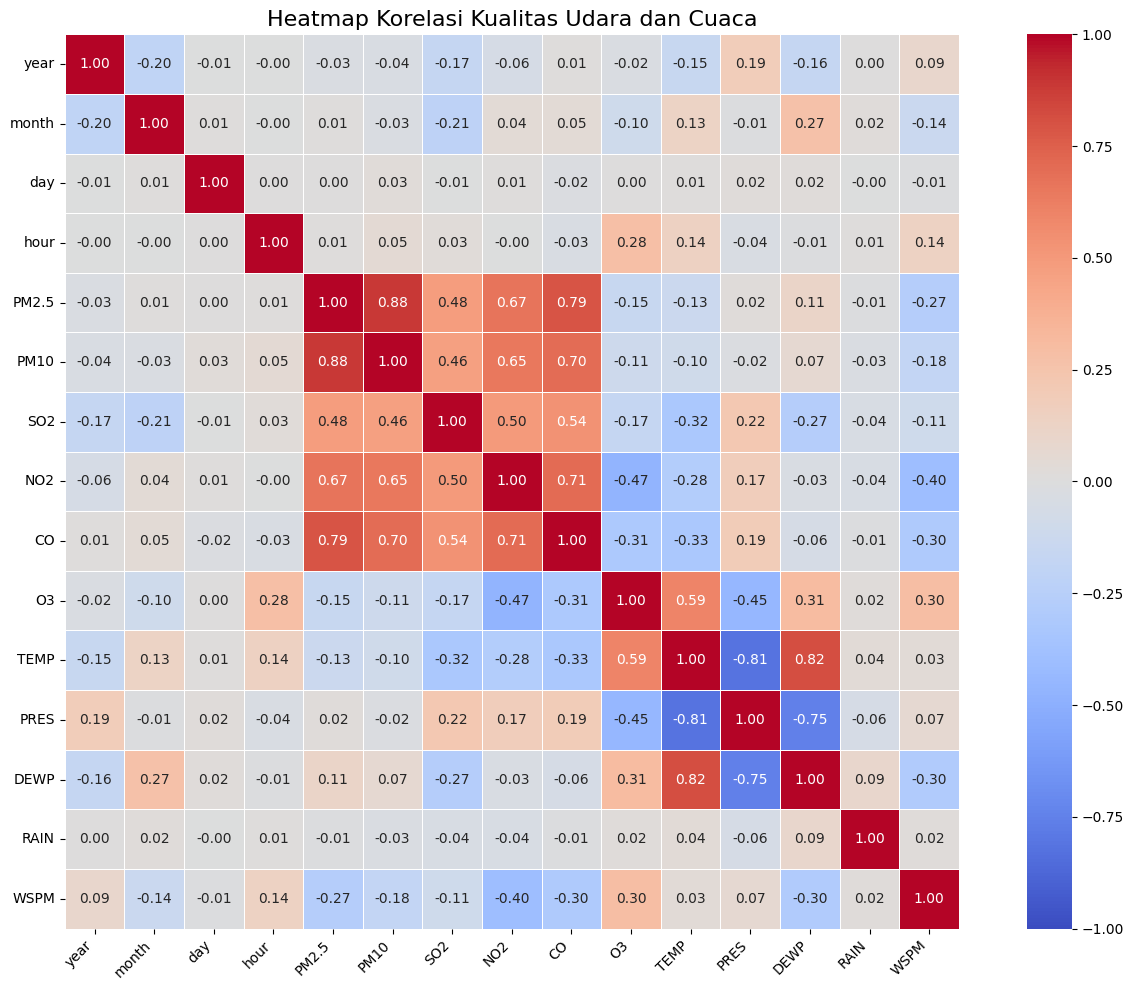

In [80]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,          
    fmt=".2f",           
    cmap='coolwarm',     
    vmin=-1, vmax=1, 
    square=True,      
    linewidths=.5  
)
plt.title('Heatmap Korelasi Kualitas Udara dan Cuaca', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

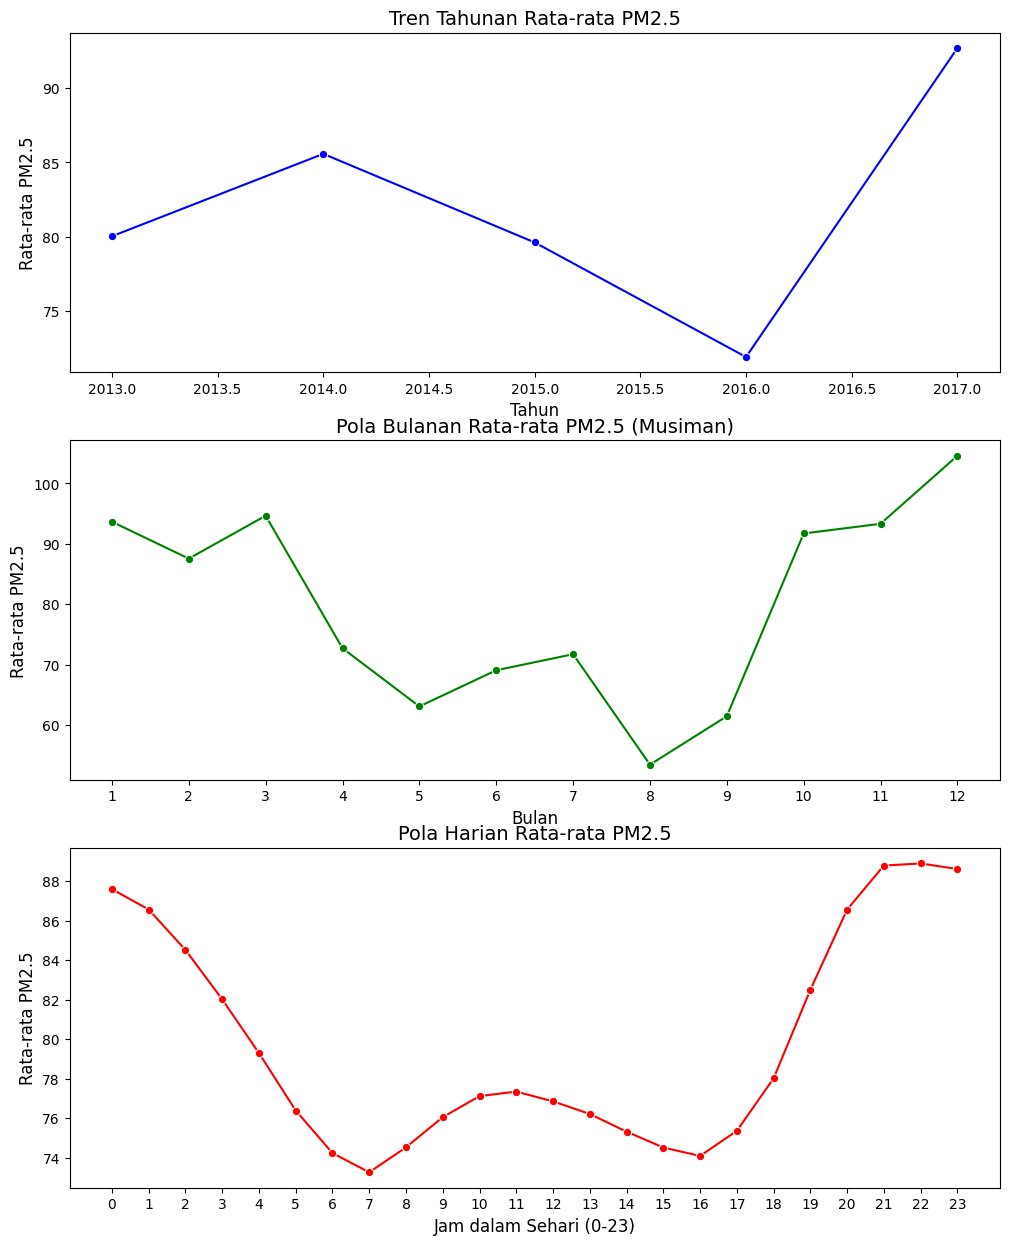

In [81]:
fig, axes = plt.subplots(3, 1, figsize=(12, 15))
sns.lineplot(ax=axes[0], data=all_data_df, x='year', y='PM2.5', marker='o', errorbar=None, color='b')
axes[0].set_title('Tren Tahunan Rata-rata PM2.5', fontsize=14)
axes[0].set_xlabel('Tahun', fontsize=12)
axes[0].set_ylabel('Rata-rata PM2.5', fontsize=12)

sns.lineplot(ax=axes[1], data=all_data_df, x='month', y='PM2.5', marker='o', errorbar=None, color='g')
axes[1].set_title('Pola Bulanan Rata-rata PM2.5 (Musiman)', fontsize=14)
axes[1].set_xlabel('Bulan', fontsize=12)
axes[1].set_ylabel('Rata-rata PM2.5', fontsize=12)
axes[1].set_xticks(range(1, 13))

sns.lineplot(ax=axes[2], data=all_data_df, x='hour', y='PM2.5', marker='o', errorbar=None, color='r')
axes[2].set_title('Pola Harian Rata-rata PM2.5', fontsize=14)
axes[2].set_xlabel('Jam dalam Sehari (0-23)', fontsize=12)
axes[2].set_ylabel('Rata-rata PM2.5', fontsize=12)
axes[2].set_xticks(range(0, 24))

C:\Users\yanki\AppData\Local\Temp\ipykernel_2600\2511037097.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month', y='PM2.5', data=all_data_df, ax=axes[1], palette='viridis')


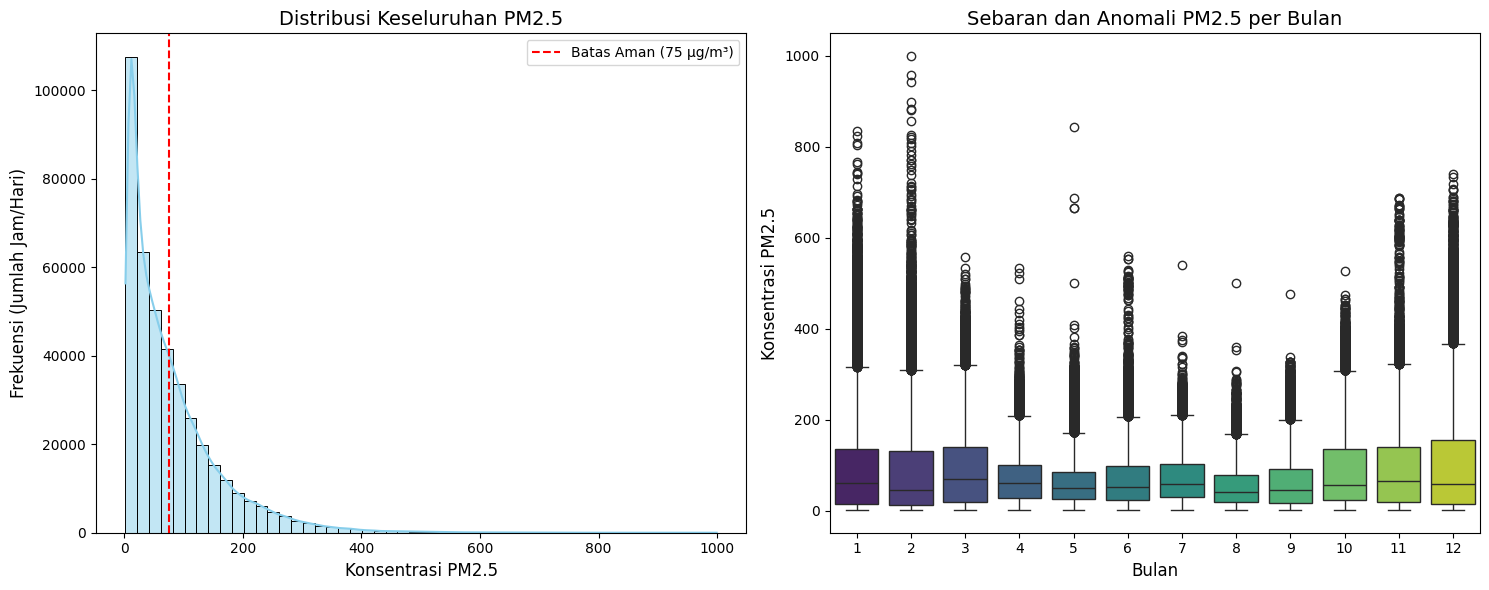

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(all_data_df['PM2.5'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Keseluruhan PM2.5', fontsize=14)
axes[0].set_xlabel('Konsentrasi PM2.5', fontsize=12)
axes[0].set_ylabel('Frekuensi (Jumlah Jam/Hari)', fontsize=12)

axes[0].axvline(x=75, color='red', linestyle='--', label='Batas Aman (75 µg/m³)')
axes[0].legend()

sns.boxplot(x='month', y='PM2.5', data=all_data_df, ax=axes[1], palette='viridis')
axes[1].set_title('Sebaran dan Anomali PM2.5 per Bulan', fontsize=14)
axes[1].set_xlabel('Bulan', fontsize=12)
axes[1].set_ylabel('Konsentrasi PM2.5', fontsize=12)

plt.tight_layout()
plt.show()

In [83]:
np.random.seed(42)
dates = pd.date_range(start='2013-01-01', periods=100, freq='D')

<Figure size 1200x600 with 0 Axes>

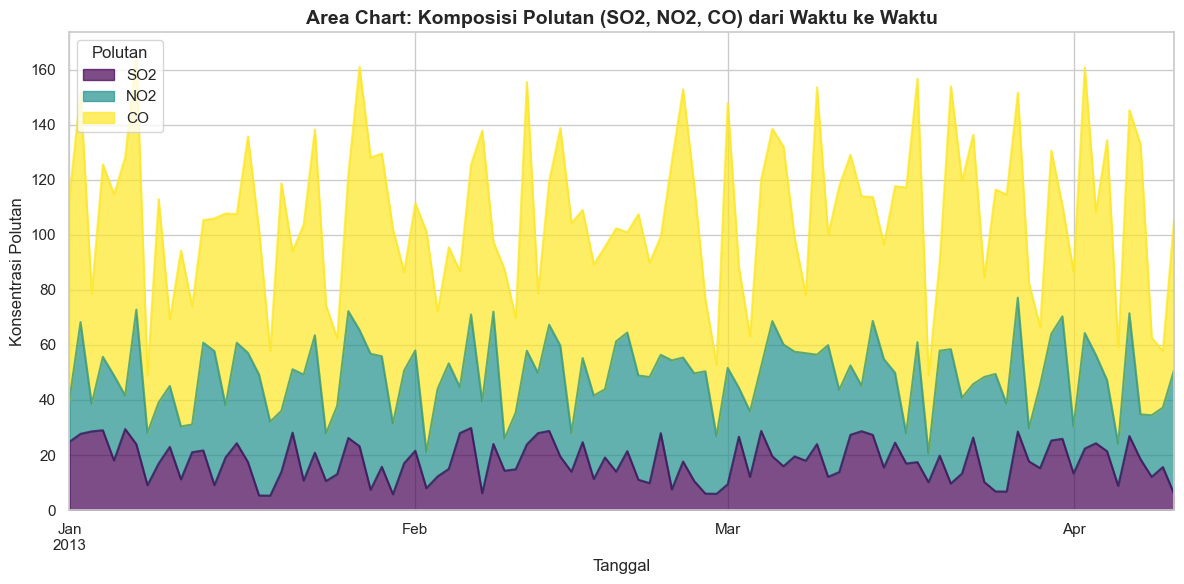

In [88]:
data = {
    'SO2': np.random.uniform(5, 30, 100),
    'NO2': np.random.uniform(10, 50, 100),
    # CO biasanya nilainya jauh lebih besar (ratusan/ribuan), 
    # di sini kita simulasikan dalam skala yang disesuaikan
    'CO': np.random.uniform(20, 100, 100), 
    'TEMP': np.random.uniform(15, 35, 100) + np.sin(np.linspace(0, 10, 100))*5,
    'PRES': np.random.uniform(1000, 1020, 100),
    'DEWP': np.random.uniform(5, 25, 100) + np.sin(np.linspace(0, 10, 100))*3,
    'WSPM': np.random.uniform(0, 8, 100)
}
df = pd.DataFrame(data, index=dates)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
df_pollutants = df[['SO2', 'NO2', 'CO']]
df_pollutants.plot.area(alpha=0.7, colormap='viridis', figsize=(12, 6))

plt.title('Area Chart: Komposisi Polutan (SO2, NO2, CO) dari Waktu ke Waktu', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Konsentrasi Polutan', fontsize=12)
plt.legend(title='Polutan', loc='upper left')
plt.tight_layout()
plt.show()